<a href="https://colab.research.google.com/github/Marina4ij/FinalProject/blob/main/FinalProject14072026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Wikipedia Web Traffic (Kaggle)
Ежедневное количество просмотров статей Википедии за 2018-2019 годы.

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn statsmodels

pmdarima not installed - using fixed SARIMA
Колонки и характеристики:
- Всего страниц: 63856
- Дней наблюдений: 730
- Пропусков (NaN): 1350886

Проводим EDA...
Итоговый размер данных: 45263994 строк
Диапазон дат: 2018-01-01 00:00:00 — 2019-12-31 00:00:00

Топ-5 страниц по среднему трафику:
                                                            mean  \
Page                                                               
Main_Page_en.wikipedia_all-access_all-agents        1.687435e+07   
Main_Page_en.wikipedia_mobile-web_all-agents        2.763755e+06   
Special:Search_en.wikipedia_all-access_all-agents   1.866894e+06   
Main_Page_en.wikipedia_all-access_spider            1.397412e+06   
Wikipedia:Hauptseite_de.wikipedia_desktop_all-a...  7.472705e+05   

                                                             std        min  \
Page                                                                          
Main_Page_en.wikipedia_all-access_all-agents        2.527575e+06  8701089.

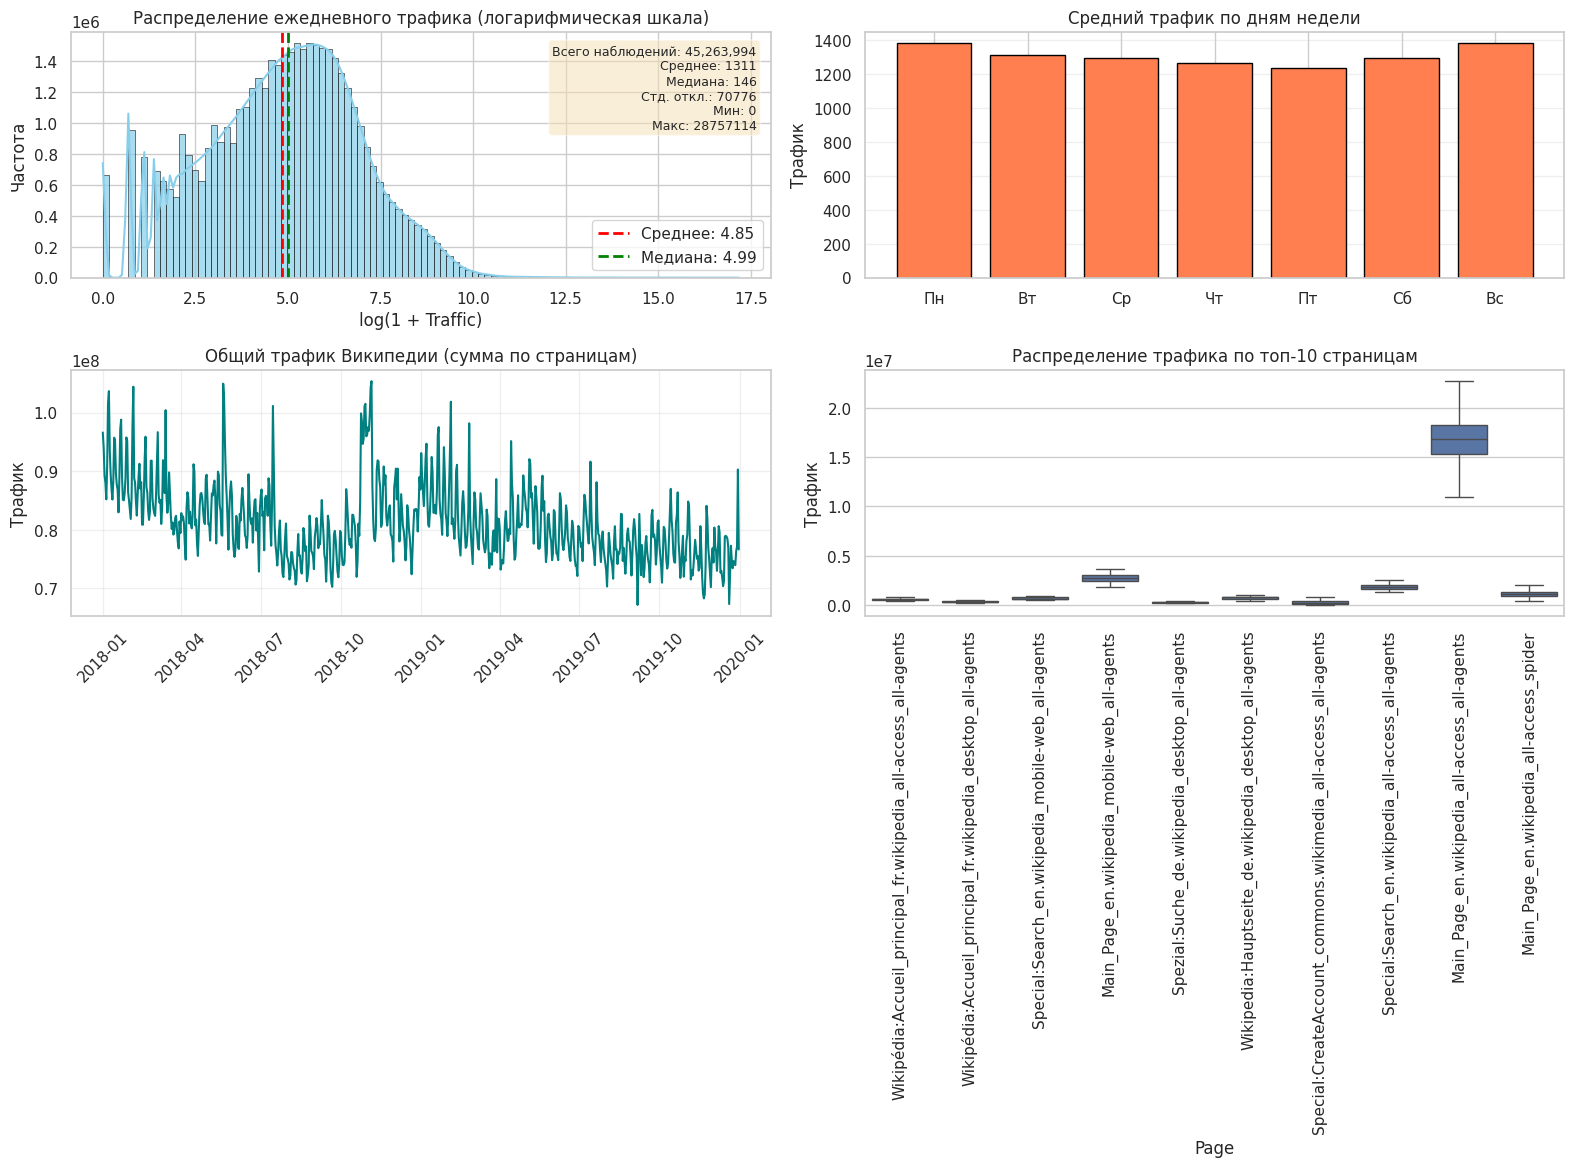


Предобработка данных...
Выбрана страница: Main_Page_en.wikipedia_all-access_all-agents
Размер данных после feature engineering: (700, 14)

Статистика Traffic:
  Mean: 17110010, Std: 2351953
  Min: 11514025, Max: 28757114

Train: 595 obs, Test: 105 obs
Признаков: 13

ОБУЧЕНИЕ МОДЕЛЕЙ С РАННЕЙ ОСТАНОВКОЙ

[1/7] Linear Regression...
    done
[2/7] Ridge Regression...
    done

[3/7] Random Forest с ранней остановкой...
 Iter |  Trees |   Train RMSE |     Val RMSE | Status              
---------------------------------------------------------------------------
   10 |     10 |      1341965 |      1792509 | IMPROVED
   20 |     20 |      1282004 |      1716367 | IMPROVED
   30 |     30 |      1255631 |      1685953 | IMPROVED
   40 |     40 |      1249229 |      1691358 | wait (1/15)
   50 |     50 |      1249663 |      1694624 | wait (2/15)
   60 |     60 |      1249884 |      1693416 | wait (3/15)
   70 |     70 |      1248219 |      1697196 | wait (4/15)
   80 |     80 |      1247603 |

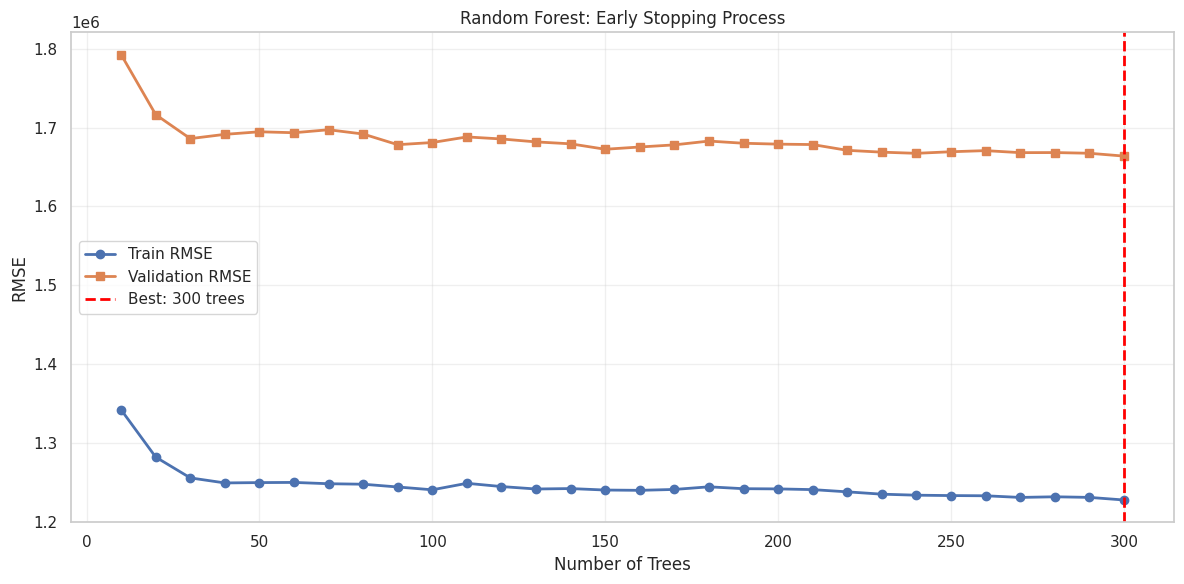

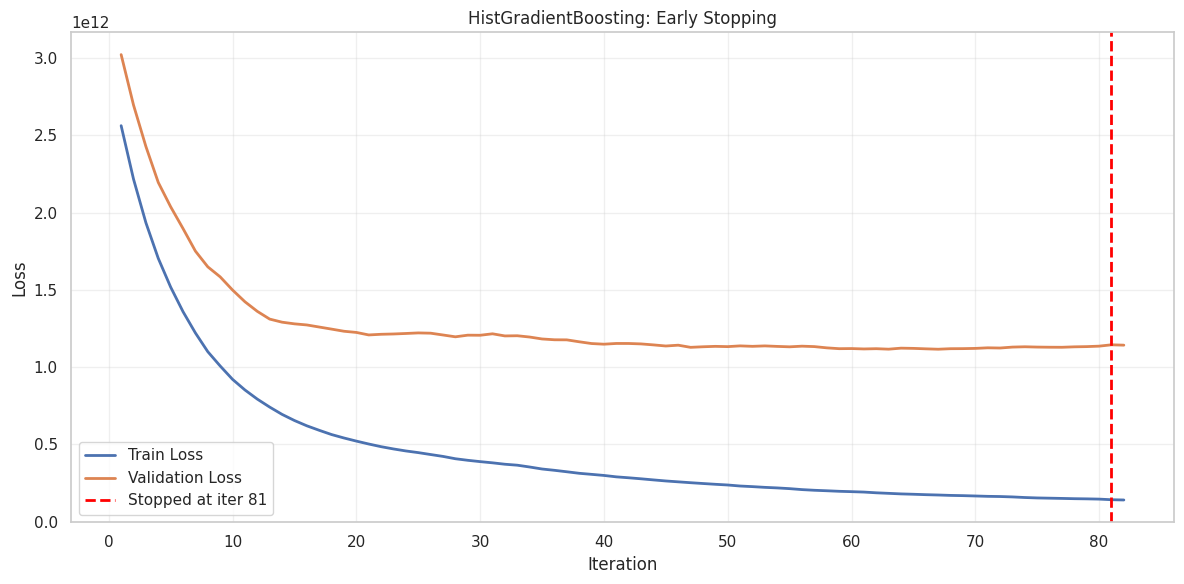

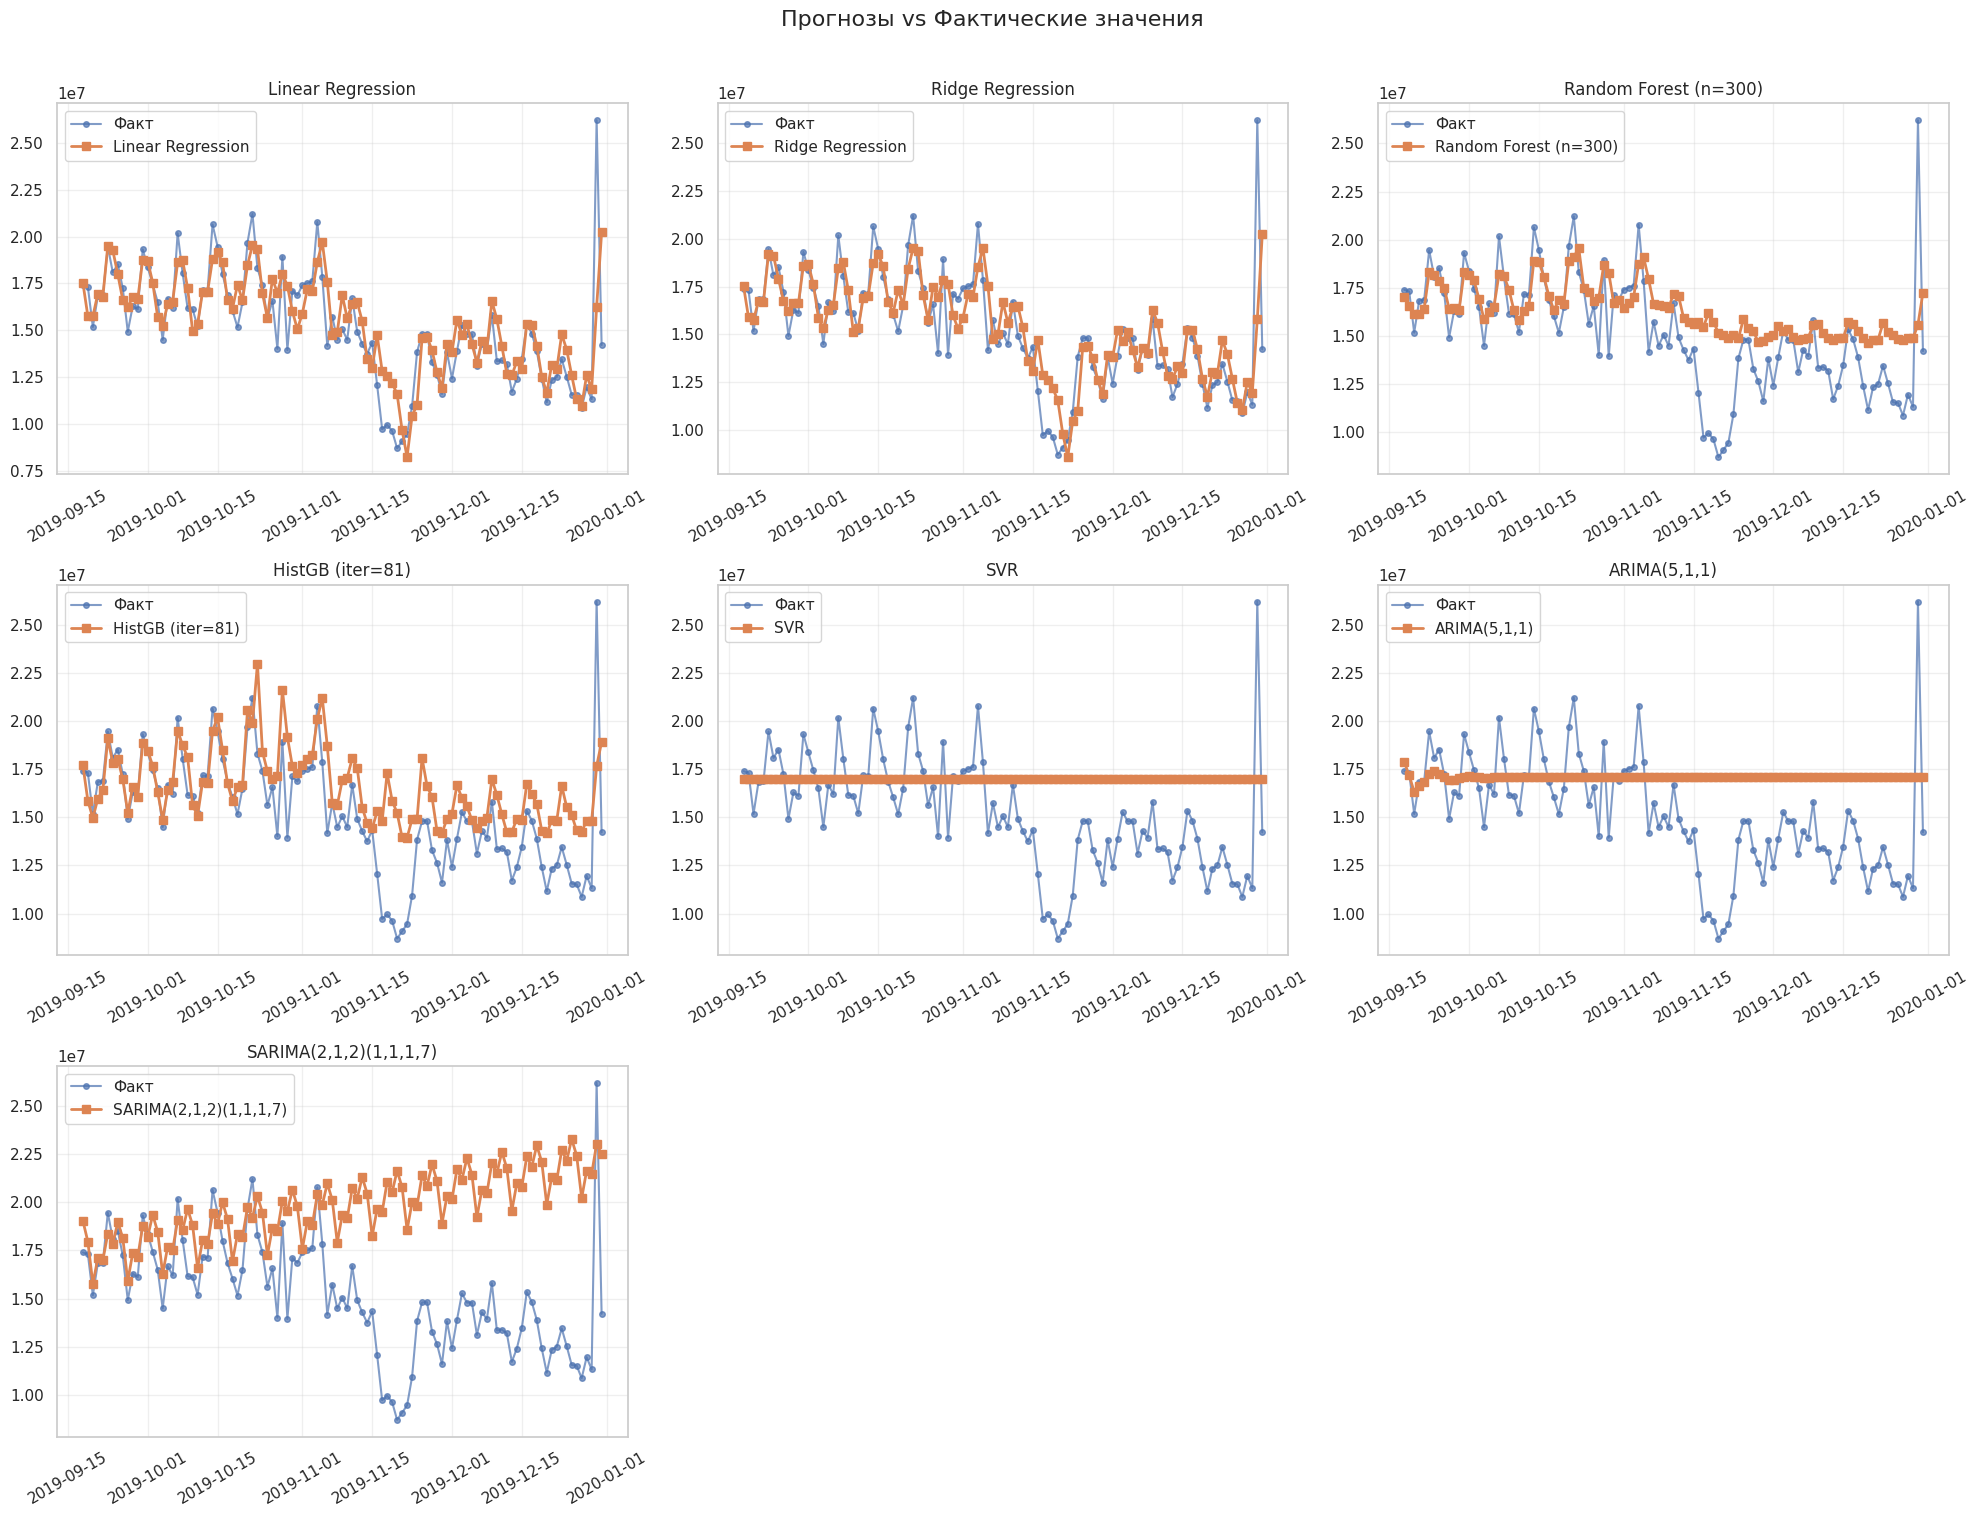

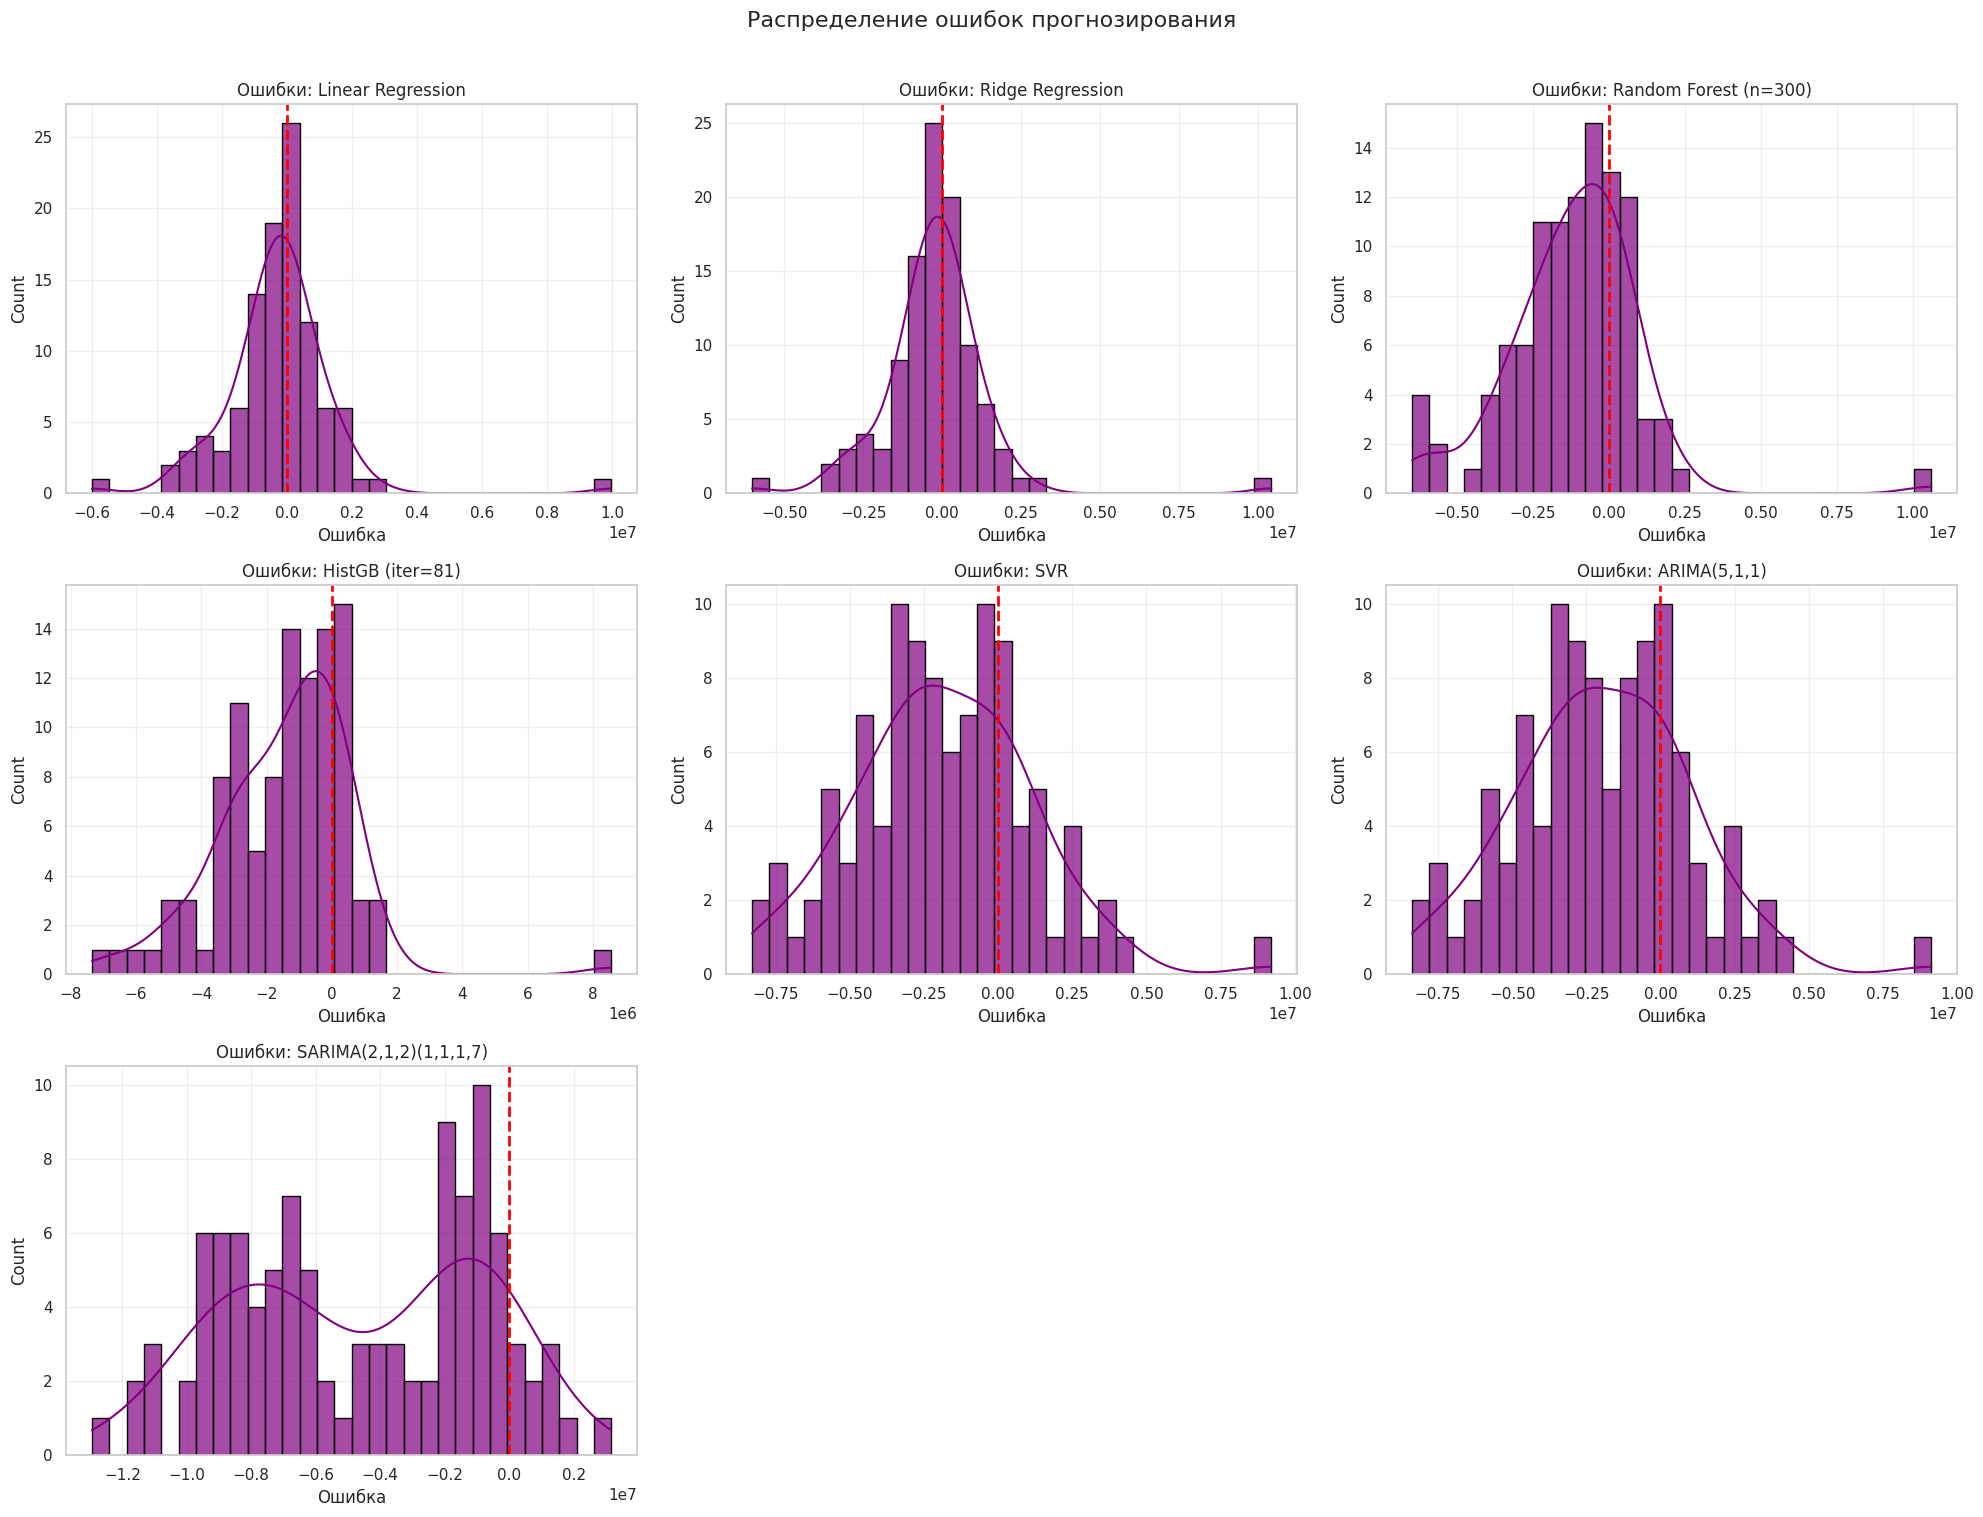

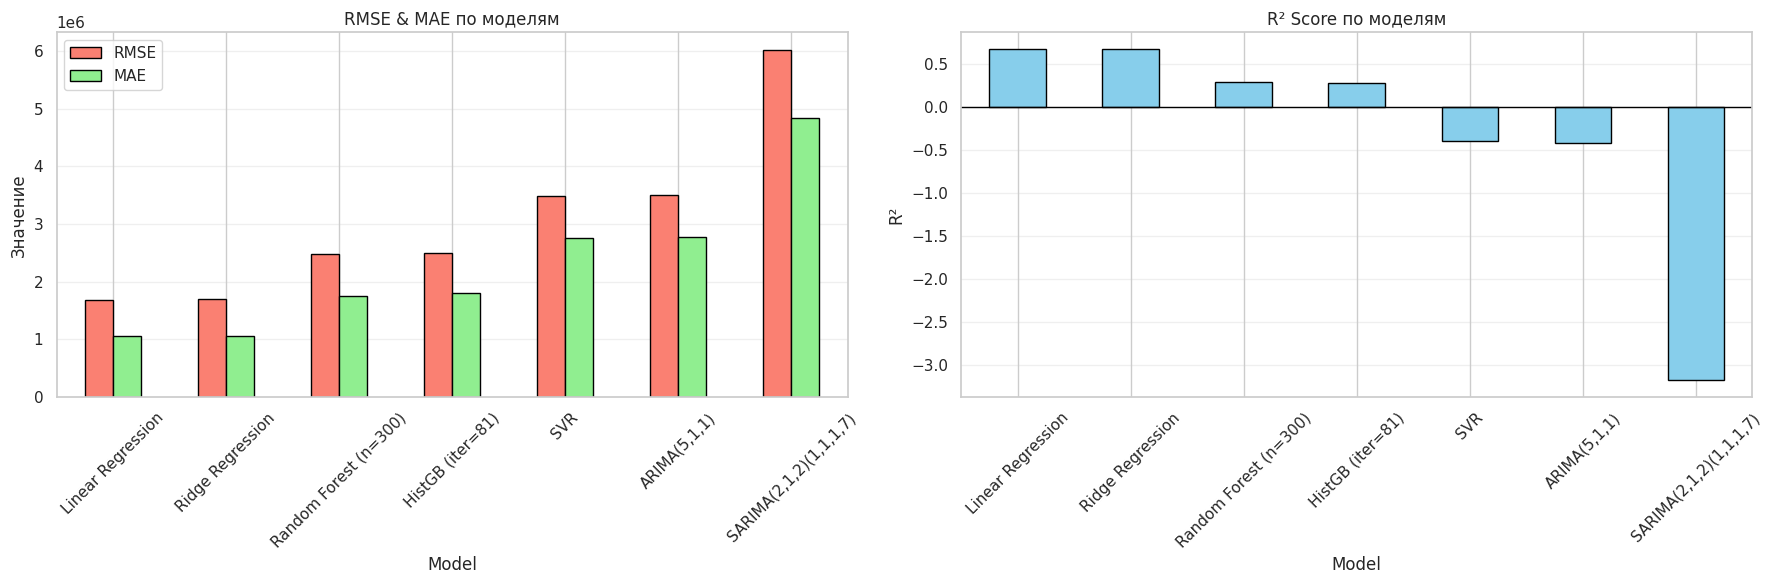

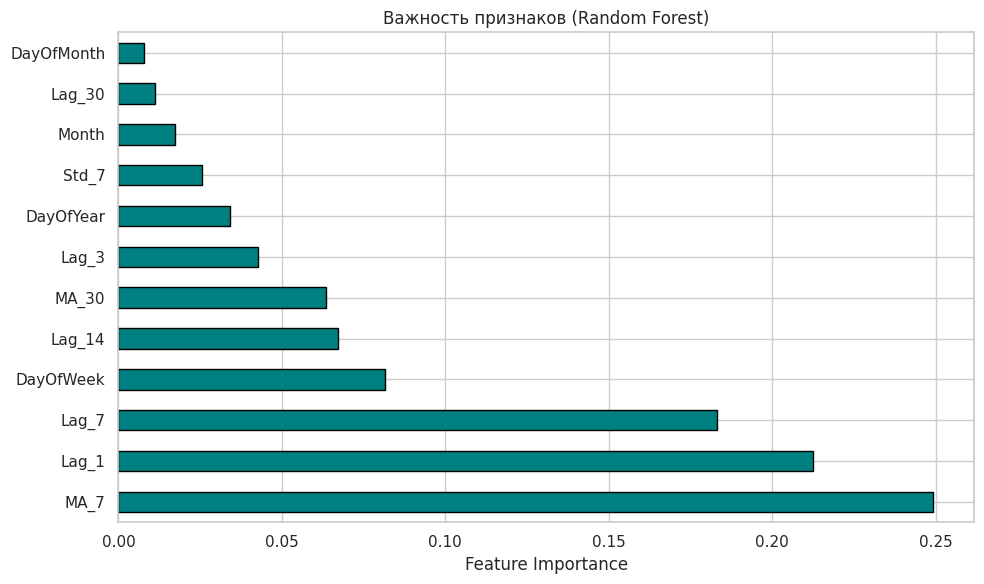

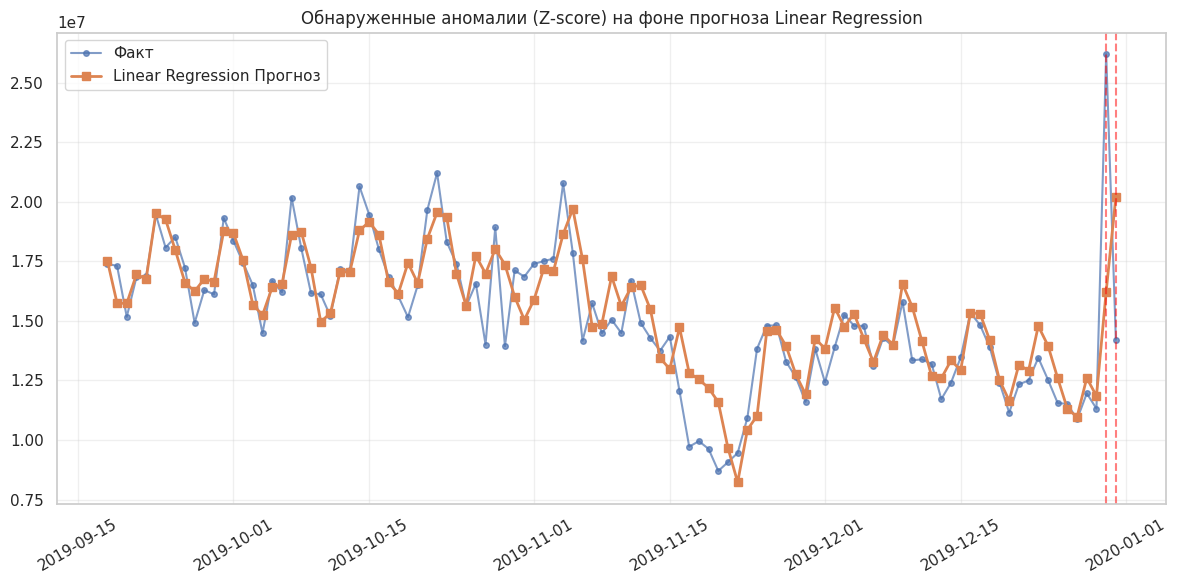

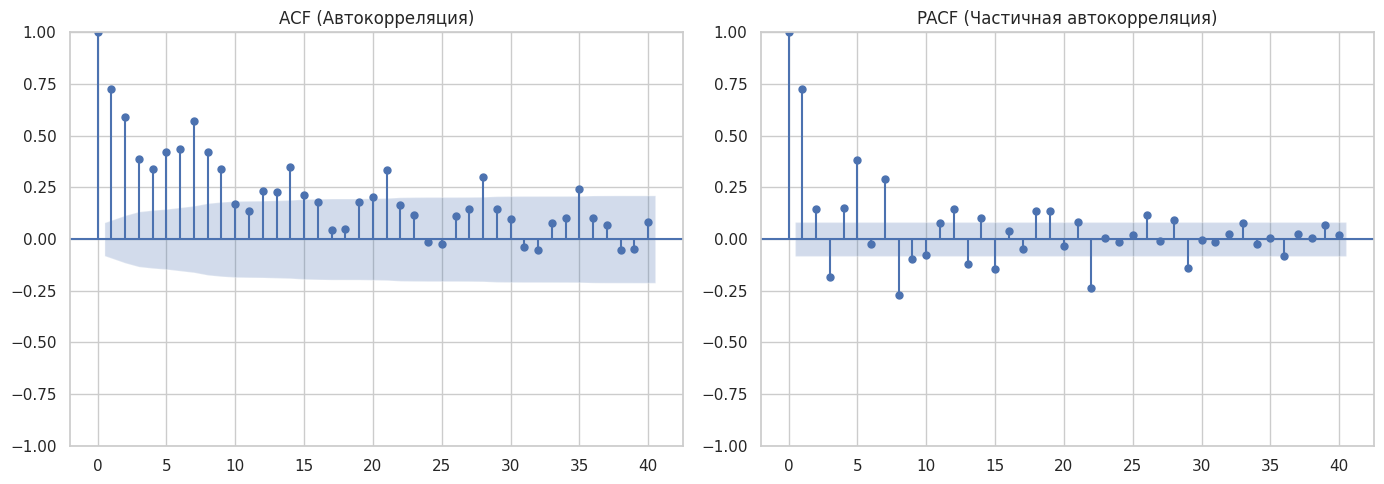


Все графики сохранены в директории.
Проект завершён успешно!


In [2]:
# -*- coding: utf-8 -*-
"""
Wikipedia Web Traffic Analysis - WITH EARLY STOPPING
Полный рабочий код
"""

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import IsolationForest

try:
    from pmdarima import auto_arima
    PMDARIMA_AVAILABLE = True
    print("pmdarima available")
except ImportError:
    PMDARIMA_AVAILABLE = False
    print("pmdarima not installed - using fixed SARIMA")

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

# ==========================================
# ФУНКЦИЯ EARLY STOPPING ДЛЯ RANDOM FOREST
# ==========================================
def random_forest_with_early_stopping(X_train, y_train, X_val, y_val,
                                       max_estimators=300,
                                       patience=15,
                                       min_improvement=100):
    """
    Random Forest с ранней остановкой через мониторинг валидационной ошибки.
    Проверяет качество каждые 10 деревьев.
    """
    history = {'n_estimators': [], 'train_rmse': [], 'val_rmse': []}
    best_rmse = float('inf')
    best_n_estimators = 10
    no_improve_count = 0

    print(f"{'Iter':>5} | {'Trees':>6} | {'Train RMSE':>12} | {'Val RMSE':>12} | {'Status':<20}")
    print("-" * 75)

    # Проверяем каждые 10 деревьев
    for i in range(10, max_estimators + 1, 10):
        rf_temp = RandomForestRegressor(
            n_estimators=i,
            max_depth=10,
            min_samples_split=20,
            min_samples_leaf=10,
            max_features='sqrt',
            random_state=42,
            n_jobs=-1
        )
        rf_temp.fit(X_train, y_train)

        train_pred = rf_temp.predict(X_train)
        val_pred = rf_temp.predict(X_val)

        train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
        val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

        history['n_estimators'].append(i)
        history['train_rmse'].append(train_rmse)
        history['val_rmse'].append(val_rmse)

        status = ""
        if val_rmse < best_rmse - min_improvement:
            best_rmse = val_rmse
            best_n_estimators = i
            no_improve_count = 0
            status = "IMPROVED"
        else:
            no_improve_count += 1
            status = f"wait ({no_improve_count}/{patience})"

        print(f"{i:5d} | {i:6d} | {train_rmse:12.0f} | {val_rmse:12.0f} | {status}")

        if no_improve_count >= patience:
            print(f"\nEarly stopping at {i} trees (best: {best_n_estimators})")
            break

    # Создаём ФИНАЛЬНУЮ модель с лучшим числом деревьев
    rf_final = RandomForestRegressor(
        n_estimators=best_n_estimators,
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
    rf_final.fit(X_train, y_train)

    return rf_final, best_n_estimators, history

# ==========================================
# 1. ЗАГРУЗКА ДАННЫХ
# ==========================================
df = pd.read_csv("train/Wiki_Page_views.csv")

print("Колонки и характеристики:")
print(f"- Всего страниц: {len(df)}")
print(f"- Дней наблюдений: {len(df.columns) - 1}")
print(f"- Пропусков (NaN): {df.iloc[:, 1:].isna().sum().sum()}")

# ==========================================
# 2. EDA
# ==========================================
print("\nПроводим EDA...")

date_columns = [col for col in df.columns if col != "Page"]
df_long = df.melt(id_vars="Page", value_vars=date_columns, var_name="Date", value_name="Traffic")

def parse_date_column(date_series):
    try:
        return pd.to_datetime(date_series)
    except:
        pass

    date_str = date_series.astype(str)
    sample = date_str.iloc[0]

    if len(sample) == 8 and sample.isdigit():
        return pd.to_datetime(date_str, format="%Y%m%d")
    elif len(sample) == 10 and sample.isdigit():
        return pd.to_datetime(date_str.str[:8], format="%Y%m%d")
    elif " " in sample:
        return pd.to_datetime(date_str.str[:10], format="%Y-%m-%d")
    elif "-" in sample and len(sample) == 10:
        return pd.to_datetime(date_str, format="%Y-%m-%d")
    else:
        return pd.to_datetime(date_str, infer_datetime_format=True, errors='coerce')

df_long["Date"] = parse_date_column(df_long["Date"])
df_long = df_long.dropna(subset=["Date", "Traffic"])

print(f"Итоговый размер данных: {len(df_long)} строк")
print(f"Диапазон дат: {df_long['Date'].min()} — {df_long['Date'].max()}")

# Статистика
stats = df_long.groupby("Page")["Traffic"].agg(["mean", "std", "min", "max"])
print("\nТоп-5 страниц по среднему трафику:")
print(stats.sort_values("mean", ascending=False).head())

# Визуализация EDA
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Распределение трафика (логарифмическая шкала)
traffic_log = np.log1p(df_long["Traffic"])
sns.histplot(traffic_log, bins=100, kde=True, ax=axes[0,0], color="skyblue", edgecolor='black', alpha=0.7)
axes[0,0].set_title("Распределение ежедневного трафика (логарифмическая шкала)")
axes[0,0].set_xlabel("log(1 + Traffic)")
axes[0,0].set_ylabel("Частота")

mean_log = traffic_log.mean()
median_log = traffic_log.median()
axes[0,0].axvline(mean_log, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_log:.2f}')
axes[0,0].axvline(median_log, color='green', linestyle='--', linewidth=2, label=f'Медиана: {median_log:.2f}')
axes[0,0].legend()

stats_text = f"Всего наблюдений: {len(df_long):,}\n"
stats_text += f"Среднее: {df_long['Traffic'].mean():.0f}\n"
stats_text += f"Медиана: {df_long['Traffic'].median():.0f}\n"
stats_text += f"Стд. откл.: {df_long['Traffic'].std():.0f}\n"
stats_text += f"Мин: {df_long['Traffic'].min():.0f}\n"
stats_text += f"Макс: {df_long['Traffic'].max():.0f}"
axes[0,0].text(0.98, 0.95, stats_text, transform=axes[0,0].transAxes,
               verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
               fontsize=9)

# 2. Недельная сезонность
df_long["DayOfWeek"] = df_long["Date"].dt.dayofweek
weekly = df_long.groupby("DayOfWeek")["Traffic"].mean()
days = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
axes[0,1].bar(days, weekly, color="coral", edgecolor='black')
axes[0,1].set_title("Средний трафик по дням недели")
axes[0,1].set_ylabel("Трафик")
axes[0,1].grid(axis='y', alpha=0.3)

# 3. Динамика по времени
daily_agg = df_long.groupby("Date")["Traffic"].sum()
axes[1,0].plot(daily_agg.index, daily_agg.values, linewidth=1.5, color="teal")
axes[1,0].set_title("Общий трафик Википедии (сумма по страницам)")
axes[1,0].set_ylabel("Трафик")
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(alpha=0.3)

# 4. Коробчатые диаграммы топ-10 страниц
top_pages = stats.sort_values("mean", ascending=False).index[:10]
df_top = df_long[df_long["Page"].isin(top_pages)]
sns.boxplot(data=df_top, x="Page", y="Traffic", ax=axes[1,1], showfliers=False)
axes[1,1].tick_params(axis='x', rotation=90)
axes[1,1].set_title("Распределение трафика по топ-10 страницам")
axes[1,1].set_ylabel("Трафик")

plt.tight_layout()
plt.savefig("1_eda_plots.png", dpi=150)
plt.show()

# ==========================================
# 3. ПРЕДОБРАБОТКА
# ==========================================
print("\nПредобработка данных...")

df_long["Traffic"] = pd.to_numeric(df_long["Traffic"], errors="coerce")
df_long = df_long.dropna(subset=["Traffic"])

page_stats = df_long.groupby("Page")["Traffic"].mean()
target_page = page_stats.idxmax()
print(f"Выбрана страница: {target_page}")

ts_data = df_long[df_long["Page"] == target_page].copy()
ts_data = ts_data[["Date", "Traffic"]].copy()
ts_data.sort_values("Date", inplace=True)
ts_data.set_index("Date", inplace=True)

ts_data["Traffic"] = ts_data["Traffic"].interpolate(method="linear").bfill().ffill()

# Feature Engineering
ts_data["DayOfWeek"] = ts_data.index.dayofweek
ts_data["DayOfMonth"] = ts_data.index.day
ts_data["Month"] = ts_data.index.month
ts_data["DayOfYear"] = ts_data.index.dayofyear
ts_data["IsWeekend"] = (ts_data["DayOfWeek"] >= 5).astype(int)

for lag in [1, 3, 7, 14, 30]:
    ts_data[f"Lag_{lag}"] = ts_data["Traffic"].shift(lag)

ts_data["MA_7"] = ts_data["Traffic"].rolling(window=7).mean()
ts_data["MA_30"] = ts_data["Traffic"].rolling(window=30).mean()
ts_data["Std_7"] = ts_data["Traffic"].rolling(window=7).std()

ts_data.dropna(inplace=True)

print(f"Размер данных после feature engineering: {ts_data.shape}")

split_idx = int(len(ts_data) * 0.85)
train = ts_data.iloc[:split_idx]
test = ts_data.iloc[split_idx:]

X_train = train.drop("Traffic", axis=1)
y_train = train["Traffic"]
X_test = test.drop("Traffic", axis=1)
y_test = test["Traffic"]

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print(f"\nСтатистика Traffic:")
print(f"  Mean: {y_train.mean():.0f}, Std: {y_train.std():.0f}")
print(f"  Min: {y_train.min():.0f}, Max: {y_train.max():.0f}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTrain: {X_train.shape[0]} obs, Test: {X_test.shape[0]} obs")
print(f"Признаков: {X_train.shape[1]}")

# ==========================================
# 4. ОБУЧЕНИЕ МОДЕЛЕЙ С EARLY STOPPING
# ==========================================
print("\n" + "="*80)
print("ОБУЧЕНИЕ МОДЕЛЕЙ С РАННЕЙ ОСТАНОВКОЙ")
print("="*80)

results = {}

# Создаём валидационную выборку для early stopping
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# 1. Linear Regression
print("\n[1/7] Linear Regression...")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)
results["Linear Regression"] = pred_lr
print("    done")

# 2. Ridge Regression
print("[2/7] Ridge Regression...")
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_scaled, y_train)
pred_ridge = ridge.predict(X_test_scaled)
results["Ridge Regression"] = pred_ridge
print("    done")

# 3. Random Forest с EARLY STOPPING
print("\n[3/7] Random Forest с ранней остановкой...")
rf, best_n_estimators, rf_history = random_forest_with_early_stopping(
    X_train_sub, y_train_sub, X_val, y_val,
    max_estimators=300,
    patience=15,
    min_improvement=100
)
pred_rf = rf.predict(X_test)
results[f"Random Forest (n={best_n_estimators})"] = pred_rf
print(f"Оптимальное число деревьев: {best_n_estimators}")

# 4. HistGradientBoosting с EARLY STOPPING
print("\n[4/7] HistGradientBoosting с ранней остановкой...")
hgb = HistGradientBoostingRegressor(
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    tol=1e-4,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    verbose=0
)
hgb.fit(X_train_sub, y_train_sub)
print(f"Остановлено на итерации: {hgb.n_iter_}")
pred_hgb = hgb.predict(X_test)
results[f"HistGB (iter={hgb.n_iter_})"] = pred_hgb

# 5. SVR
print("\n[5/7] SVR...")
svr = SVR(kernel='rbf', C=10, epsilon=0.1, max_iter=10000)
svr.fit(X_train_scaled, y_train)
pred_svr = svr.predict(X_test_scaled)
results["SVR"] = pred_svr
print("    done")

# 6. ARIMA
print("\n[6/7] ARIMA...")
try:
    arima_model = ARIMA(y_train, order=(5,1,1))
    arima_fit = arima_model.fit()
    pred_arima = arima_fit.forecast(steps=len(y_test))

    if len(pred_arima) < len(y_test):
        pred_arima = np.concatenate([pred_arima, np.full(len(y_test)-len(pred_arima), y_train.iloc[-1])])
    elif len(pred_arima) > len(y_test):
        pred_arima = pred_arima[:len(y_test)]

    results["ARIMA(5,1,1)"] = pred_arima
    print("    ARIMA(5,1,1) - done")
except Exception as e:
    print(f"    ARIMA failed: {e}")

# 7. SARIMA
print("[7/7] SARIMA...")
try:
    if PMDARIMA_AVAILABLE:
        auto_model = auto_arima(
            y_train, seasonal=True, m=7,
            trace=False, error_action='ignore',
            suppress_warnings=True, stepwise=True
        )
        sarima_name = f"SARIMA{auto_model.order}x{auto_model.seasonal_order}"
        pred_sarima = auto_model.predict(n_periods=len(y_test))

        if len(pred_sarima) < len(y_test):
            pred_sarima = np.concatenate([pred_sarima, np.full(len(y_test)-len(pred_sarima), y_train.iloc[-1])])
        elif len(pred_sarima) > len(y_test):
            pred_sarima = pred_sarima[:len(y_test)]

        results[sarima_name] = pred_sarima
        print(f"    SARIMA - done: {sarima_name}")
    else:
        sarima_model = SARIMAX(y_train, order=(2,1,2), seasonal_order=(1,1,1,7),
                               enforce_stationarity=False, enforce_invertibility=False)
        sarima_fit = sarima_model.fit(disp=False)
        pred_sarima = sarima_fit.forecast(steps=len(y_test))

        if len(pred_sarima) < len(y_test):
            pred_sarima = np.concatenate([pred_sarima, np.full(len(y_test)-len(pred_sarima), y_train.iloc[-1])])
        elif len(pred_sarima) > len(y_test):
            pred_sarima = pred_sarima[:len(y_test)]

        results["SARIMA(2,1,2)(1,1,1,7)"] = pred_sarima
        print("    SARIMA(2,1,2)(1,1,1,7) - done")
except Exception as e:
    print(f"    SARIMA failed: {e}")

# ==========================================
# 5. ОЦЕНКА КАЧЕСТВА
# ==========================================
print("\n" + "="*80)
print("МЕТРИКИ МОДЕЛЕЙ:")
print("="*80)
metrics = []
for name, preds in results.items():
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    metrics.append({"Model": name, "RMSE": rmse, "MAE": mae, "R²": r2})
    print(f"{name:35} | RMSE: {rmse:10.0f} | MAE: {mae:10.0f} | R²: {r2:6.3f}")

metrics_df = pd.DataFrame(metrics).set_index("Model")

best_model = metrics_df["RMSE"].idxmin()
print(f"\nЛучшая модель: {best_model}")

# Диагностика переобучения
print("\n" + "="*80)
print("ДИАГНОСТИКА ПЕРЕОБУЧЕНИЯ (Train vs Test RMSE):")
print("="*80)

models_for_check = {
    "Linear Regression": (lr, X_train_scaled, X_test_scaled, y_train, y_test, False),
    "Ridge Regression": (ridge, X_train_scaled, X_test_scaled, y_train, y_test, False),
    f"Random Forest (n={best_n_estimators})": (rf, X_train, X_test, y_train, y_test, False),
    "SVR": (svr, X_train_scaled, X_test_scaled, y_train, y_test, False)
}

for name, (model, X_tr, X_te, y_tr, y_te, is_log) in models_for_check.items():
    train_pred = model.predict(X_tr)
    test_pred = model.predict(X_te)

    train_rmse = np.sqrt(mean_squared_error(y_tr, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_te, test_pred))
    gap = test_rmse - train_rmse

    print(f"{name:35} | Train RMSE: {train_rmse:10.0f} | Test RMSE: {test_rmse:10.0f} | Gap: {gap:10.0f}")

# ==========================================
# 6. ПОИСК АНОМАЛИЙ
# ==========================================
print("\n" + "="*80)
print("ПОИСК АНОМАЛИЙ:")
print("="*80)
residuals = y_test - results[best_model]

iso = IsolationForest(contamination=0.05, random_state=42)
iso_pred = iso.fit_predict(X_test)
anomalies_iso = X_test[iso_pred == -1]

z_scores = np.abs((residuals - residuals.mean()) / residuals.std())
anomalies_z = test.index[z_scores > 3]

Q1, Q3 = residuals.quantile(0.25), residuals.quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 3*IQR, Q3 + 3*IQR
anomalies_iqr = test.index[(residuals < lower) | (residuals > upper)]

print(f"Isolation Forest: {len(anomalies_iso)} аномалий")
print(f"Z-score (|Z|>3): {len(anomalies_z)} аномалий")
print(f"IQR метод: {len(anomalies_iqr)} аномалий")

# ==========================================
# 7. ВИЗУАЛИЗАЦИЯ
# ==========================================
print("\n" + "="*80)
print("ГЕНЕРАЦИЯ ГРАФИКОВ:")
print("="*80)

# 1. Early Stopping - Random Forest
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(rf_history['n_estimators'], rf_history['train_rmse'], label='Train RMSE', linewidth=2, marker='o')
ax.plot(rf_history['n_estimators'], rf_history['val_rmse'], label='Validation RMSE', linewidth=2, marker='s')
ax.axvline(best_n_estimators, color='red', linestyle='--',
           label=f'Best: {best_n_estimators} trees', linewidth=2)
ax.set_xlabel('Number of Trees')
ax.set_ylabel('RMSE')
ax.set_title('Random Forest: Early Stopping Process')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("8_early_stopping_rf.png", dpi=150)
plt.show()

# 2. Early Stopping - HistGradientBoosting
try:
    fig, ax = plt.subplots(figsize=(12, 6))
    val_scores = [-s for s in hgb.validation_score_]
    train_scores = [-s for s in hgb.train_score_]
    iterations = list(range(1, len(train_scores) + 1))
    ax.plot(iterations, train_scores, label='Train Loss', linewidth=2)
    ax.plot(iterations, val_scores, label='Validation Loss', linewidth=2)
    ax.axvline(hgb.n_iter_, color='red', linestyle='--',
               label=f'Stopped at iter {hgb.n_iter_}', linewidth=2)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')
    ax.set_title('HistGradientBoosting: Early Stopping')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("9_early_stopping_hgb.png", dpi=150)
    plt.show()
except Exception as e:
    print(f"HistGB visualization skipped: {e}")

# 3. Прогнозы vs Факт
n_models = len(results)
n_rows = (n_models + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(20, 5*n_rows))
axes_flat = axes.flatten()

for i, (name, preds) in enumerate(results.items()):
    axes_flat[i].plot(y_test.index, y_test.values, "o-", label="Факт", markersize=4, alpha=0.7)
    axes_flat[i].plot(y_test.index, preds, "s-", label=name, linewidth=2)
    axes_flat[i].set_title(name)
    axes_flat[i].legend()
    axes_flat[i].tick_params(axis='x', rotation=30)
    axes_flat[i].grid(alpha=0.3)

for i in range(n_models, len(axes_flat)):
    axes_flat[i].axis('off')

plt.suptitle("Прогнозы vs Фактические значения", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("2_forecast_plots.png", dpi=150, bbox_inches='tight')
plt.show()

# 4. Ошибки прогнозирования (Residuals)
fig, axes = plt.subplots(n_rows, 3, figsize=(20, 5*n_rows))
axes_flat = axes.flatten()

for i, (name, preds) in enumerate(results.items()):
    err = y_test - preds
    sns.histplot(err, bins=30, kde=True, ax=axes_flat[i], color="purple", edgecolor='black', alpha=0.7)
    axes_flat[i].axvline(0, color="red", linestyle="--", linewidth=2)
    axes_flat[i].set_title(f"Ошибки: {name}")
    axes_flat[i].set_xlabel("Ошибка")
    axes_flat[i].grid(alpha=0.3)

for i in range(n_models, len(axes_flat)):
    axes_flat[i].axis('off')

plt.suptitle("Распределение ошибок прогнозирования", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("3_residuals_plots.png", dpi=150, bbox_inches='tight')
plt.show()

# 5. Сравнение метрик
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

metrics_df[["RMSE", "MAE"]].plot(kind="bar", ax=ax[0], color=["salmon", "lightgreen"], edgecolor='black')
ax[0].set_title("RMSE & MAE по моделям")
ax[0].set_ylabel("Значение")
ax[0].tick_params(axis='x', rotation=45)
ax[0].legend()
ax[0].grid(axis='y', alpha=0.3)

metrics_df["R²"].plot(kind="bar", ax=ax[1], color="skyblue", edgecolor='black')
ax[1].set_title("R² Score по моделям")
ax[1].set_ylabel("R²")
ax[1].axhline(0, color="black", linewidth=1)
ax[1].tick_params(axis='x', rotation=45)
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("4_metrics_comparison.png", dpi=150)
plt.show()

# 6. Важность признаков (Random Forest)
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
feat_imp.head(12).plot(kind="barh", color="teal", edgecolor='black')
plt.title("Важность признаков (Random Forest)")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.savefig("5_feature_importance.png", dpi=150)
plt.show()

# 7. Аномалии на графике
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, "o-", label="Факт", markersize=4, alpha=0.7)
plt.plot(y_test.index, results[best_model], "s-", label=f"{best_model} Прогноз", linewidth=2)
for date in anomalies_z:
    plt.axvline(date, color="red", linestyle="--", alpha=0.5)
plt.title(f"Обнаруженные аномалии (Z-score) на фоне прогноза {best_model}")
plt.legend()
plt.tick_params(axis='x', rotation=30)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("6_anomaly_detection.png", dpi=150)
plt.show()

# 8. ACF/PACF графики
try:
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    plot_acf(y_train, ax=axes[0], lags=40, title="ACF (Автокорреляция)")
    plot_pacf(y_train, ax=axes[1], lags=40, title="PACF (Частичная автокорреляция)")
    plt.tight_layout()
    plt.savefig("7_acf_pacf.png", dpi=150)
    plt.show()
except Exception as e:
    print(f"ACF/PACF visualization skipped: {e}")

print("\n" + "="*80)
print("Все графики сохранены в директории.")
print("Проект завершён успешно!")
print("="*80)